In [1]:
from score_espn import initial_parse_espn, score_espn
import pandas as pd

In [2]:
YEAR = 2022
DATA_DIRECTORY = f"data/{YEAR}"
DIRECTORY = f'{DATA_DIRECTORY}/espn_brackets_{YEAR}/'
OUTPUT_FILENAME = f'{DATA_DIRECTORY}/espn_brackets_{YEAR}'
NUM_CORES = 20

In [3]:
# # 2021
# MANUAL_BRACKET = [
#     1, 3, 5, 8, 9, 11, 13, 15,
#     17, 19, 21, 23, 26, 28, 30, 31,
#     33, 36, 37, 40, 41, 43, 45, 48,
#     49, 51, 54, 55, 58, 59, 62, 63,
#     1, 5, 9, 13,
#     17, 23, 26, 31,
#     33, 37, 43, 48,
#     51, 54, 58, 63,
#     1, 9,
#     17, 26,
#     33, 43,
#     54, 63,
#     1, 26, 33, 63,
#     1, 33,
#     33,
# ]
# 2022
MANUAL_BRACKET = [
    1, 4, 6, 7, 10, 11, 13, 15,
    17, 19, 21, 23, 25, 27, 29, 32,
    33, 36, 37, 39, 42, 43, 45, 47,
    49, 52, 54, 55, 58, 59, 62, 63,
    1, 7, 11, 15,
    19, 23, 27, 32,
    33, 37, 42, 47,
    49, 55, 58, 62,
    7, 15,
    19, 32,
    37, 47,
    49, 62,
    15, 19, 47, 49,
    19, 49,
    49,
]

### Test against a couple brackets to check manual entry

In [9]:
%%time
from score_espn import parse_espn, score_espn_bracket, create_actual_bracket
import os
filenames = [
    os.path.join(DIRECTORY, file)
    for file in os.listdir(DIRECTORY)
    if not file.startswith(".")
]
brackets = parse_espn(filenames[-1], 0)
actual_bracket = create_actual_bracket(manual_bracket=MANUAL_BRACKET)
scored_brackets = [
    score_espn_bracket(bracket, actual_bracket=actual_bracket)
    for bracket in list(brackets.values())[:3]
]
pd.DataFrame(scored_brackets)

/Users/Alex/Documents/MarchMadness/espn_brackets_2022/espn_brackets_99.json: 4206.612162545
CPU times: user 16.3 s, sys: 292 ms, total: 16.6 s
Wall time: 16.6 s


,id,score
0,54553750,1350
1,54492330,1020
2,54469330,1100


### Only need to run this once

In [10]:
%%time
initial_parse_espn(DIRECTORY, OUTPUT_FILENAME, num_cores=NUM_CORES, num_files=None)

CPU times: user 4min 47s, sys: 10min 29s, total: 15min 17s
Wall time: 22min 9s


### Score brackets

In [4]:
%%time
score_espn(OUTPUT_FILENAME, MANUAL_BRACKET, num_cores=NUM_CORES)

CPU times: user 3min, sys: 2min 5s, total: 5min 6s
Wall time: 6min 8s


In [5]:
test = pd.read_feather(f"{OUTPUT_FILENAME}.feather")
test.head()

,id,score
0,55978113,1130
1,66302654,1280
2,68619465,1080
3,57985445,1390
4,54486150,890


In [6]:
test.shape

(8372875, 2)

In [7]:
test.sort_values("score").tail(10)

,id,score
6003653,69129804,1640
4926727,66722899,1650
2047338,69853763,1650
193025,57794683,1650
7745523,60441229,1660
6817707,71099641,1660
446012,58743191,1660
2598867,63960028,1660
7396113,69204362,1690
640304,71036256,1710


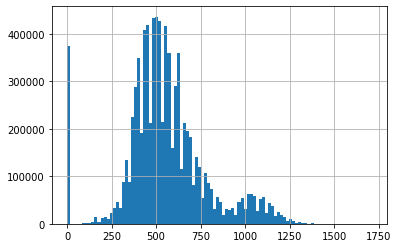

In [8]:
test["score"].hist(bins=100)

# Hypothetical Situation
## Arkansas wins out

In [5]:
MANUAL_BRACKET = [
    1, 3, 5, 8, 9, 11, 13, 15,
    17, 19, 21, 23, 26, 28, 30, 31,
    33, 36, 37, 40, 41, 43, 45, 48,
    49, 51, 54, 55, 58, 59, 62, 63,
    1, 5, 9, 13,
    17, 23, 26, 31,
    33, 37, 43, 48,
    51, 54, 58, 63,
    1, 9,
    17, 26,
    33, 43,
    54, 63,
    1, 26, 43, 63,
    1, 43,
    43,
]

### Score brackets

In [7]:
%%time
score_espn(OUTPUT_FILENAME, MANUAL_BRACKET, num_cores=NUM_CORES, new_name="espn_hypothetical")

CPU times: user 2min 35s, sys: 1min 41s, total: 4min 17s
Wall time: 5min 5s


In [11]:
test = pd.read_feather("espn_hypothetical.feather")
test.head()

,id,score
0,41116027,910
1,43553238,750
2,37179442,650
3,40348440,1200
4,42270570,470


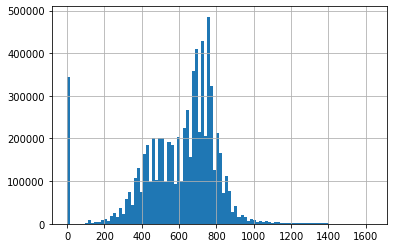

In [12]:
test["score"].hist(bins=100)